In [125]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [126]:
df = pd.read_csv('./data/processed_newsgroups.csv')
df['processed_text'] = df['processed_text'].fillna('')
print(f"Total documents loaded: {len(df)}")

Total documents loaded: 19955


In [127]:
# mapping the 20 granular categories into the 6 parent categories
category_mapping = {
    # computers
    'comp.graphics': 'comp',
    'comp.os.ms-windows.misc': 'comp',
    'comp.sys.ibm.pc.hardware': 'comp',
    'comp.sys.mac.hardware': 'comp',
    'comp.windows.x': 'comp',
    
    # recreation
    'rec.autos': 'rec',
    'rec.motorcycles': 'rec',
    'rec.sport.baseball': 'rec',
    'rec.sport.hockey': 'rec',
    
    # science
    'sci.crypt': 'sci',
    'sci.electronics': 'sci',
    'sci.med': 'sci',
    'sci.space': 'sci',
    
    # miscellaneous
    'misc.forsale': 'misc',
    
    # politics
    'talk.politics.misc': 'politics',
    'talk.politics.guns': 'politics',
    'talk.politics.mideast': 'politics',
    
    # religion
    'talk.religion.misc': 'religion',
    'alt.atheism': 'religion',
    'soc.religion.christian': 'religion'
}

In [128]:
df['parent_label'] = df['label'].map(category_mapping) # create the new target column

print("\nClass Distribution for 6 Main Categories:")
print(df['parent_label'].value_counts())


Class Distribution for 6 Main Categories:
parent_label
comp        4980
sci         3995
rec         3993
politics    3000
religion    2996
misc         991
Name: count, dtype: int64


In [129]:
X_train_raw, X_test_raw, y_train_parent, y_test_parent, y_train_child, y_test_child = train_test_split(
    df['processed_text'], df['parent_label'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

In [130]:
cv = CountVectorizer(max_df=0.95, min_df=5)

X_train_counts = cv.fit_transform(X_train_raw)
X_test_counts = cv.transform(X_test_raw)

print("Count Matrix Shape:", X_train_counts.shape)

Count Matrix Shape: (15964, 20874)


In [131]:
def compute_pmi(X_counts, y, top_k=20000):
    n_docs, n_words = X_counts.shape
    classes = np.unique(y)

    X_bin = (X_counts > 0).astype(int)

    p_w = np.asarray(X_bin.sum(axis=0)).flatten() / n_docs

    pmi_scores = np.zeros(n_words)

    for c in classes:
        mask = (y == c).values

        X_c = X_bin[mask]
        n_c = np.sum(mask)

        p_w_c = np.asarray(X_c.sum(axis=0)).flatten() / n_c

        pmi_c = np.log((p_w_c + 1e-9) / (p_w + 1e-9))

        pmi_scores = np.maximum(pmi_scores, pmi_c)

    top_indices = np.argsort(pmi_scores)[-top_k:]
    return top_indices

In [132]:
print("Training Parent Model...")

top_parent_features = compute_pmi(X_train_counts, y_train_parent, top_k=20000)

X_train_parent = X_train_counts[:, top_parent_features]
X_test_parent = X_test_counts[:, top_parent_features]

parent_classifier = MultinomialNB(alpha=0.1)
parent_classifier.fit(X_train_parent, y_train_parent)

Training Parent Model...


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [133]:
print("Training Child Expert Models...")

child_models = {}

for parent in y_train_parent.unique():

    mask = (y_train_parent == parent).values

    X_train_specific = X_train_counts[mask]
    y_train_specific = y_train_child[mask]

    top_child_features = compute_pmi(
        X_train_specific,
        y_train_specific,
        top_k=20000
    )

    X_train_child = X_train_specific[:, top_child_features]

    model = MultinomialNB(alpha=0.1)
    model.fit(X_train_child, y_train_specific)

    child_models[parent] = {'features': top_child_features, 'model': model}
    print(f"{parent} Classifier trained successfully!")

Training Child Expert Models...
sci Classifier trained successfully!
comp Classifier trained successfully!
politics Classifier trained successfully!
rec Classifier trained successfully!
religion Classifier trained successfully!
misc Classifier trained successfully!


In [134]:
print("Predicting...")

parent_preds = parent_classifier.predict(X_test_parent)

final_predictions = []

for i in range(X_test_counts.shape[0]):

    predicted_parent = parent_preds[i]

    expert = child_models[predicted_parent]

    features = expert['features']
    model = expert['model']

    doc = X_test_counts[i]
    doc_selected = doc[:, features]

    pred = model.predict(doc_selected)

    final_predictions.append(pred[0])

Predicting...


In [135]:
print("\nClassification Report: 6 CLASSES\n")

parent_acc = accuracy_score(y_test_parent, parent_preds)
print(f"Parent Accuracy: {parent_acc:.4f}\n")

print(classification_report(y_test_parent, parent_preds))


Classification Report: 6 CLASSES

Parent Accuracy: 0.8877

              precision    recall  f1-score   support

        comp       0.90      0.91      0.90       995
        misc       0.72      0.82      0.77       198
    politics       0.87      0.89      0.88       600
         rec       0.94      0.93      0.94       799
    religion       0.92      0.87      0.89       599
         sci       0.86      0.85      0.85       800

    accuracy                           0.89      3991
   macro avg       0.87      0.88      0.87      3991
weighted avg       0.89      0.89      0.89      3991



In [136]:
print("\nClassification Report: 20 SUB-CLASSES\n")

child_acc = accuracy_score(y_test_child, final_predictions)
print(f"Child Accuracy: {child_acc:.4f}\n")

print(classification_report(y_test_child, final_predictions))


Classification Report: 20 SUB-CLASSES

Child Accuracy: 0.7825

                          precision    recall  f1-score   support

             alt.atheism       0.72      0.76      0.73       200
           comp.graphics       0.70      0.74      0.72       199
 comp.os.ms-windows.misc       0.87      0.53      0.65       198
comp.sys.ibm.pc.hardware       0.60      0.75      0.67       199
   comp.sys.mac.hardware       0.68      0.76      0.72       199
          comp.windows.x       0.84      0.84      0.84       200
            misc.forsale       0.72      0.82      0.77       198
               rec.autos       0.88      0.82      0.85       200
         rec.motorcycles       0.89      0.90      0.89       199
      rec.sport.baseball       0.89      0.91      0.90       200
        rec.sport.hockey       0.93      0.92      0.92       200
               sci.crypt       0.86      0.92      0.89       200
         sci.electronics       0.76      0.64      0.70       200
           

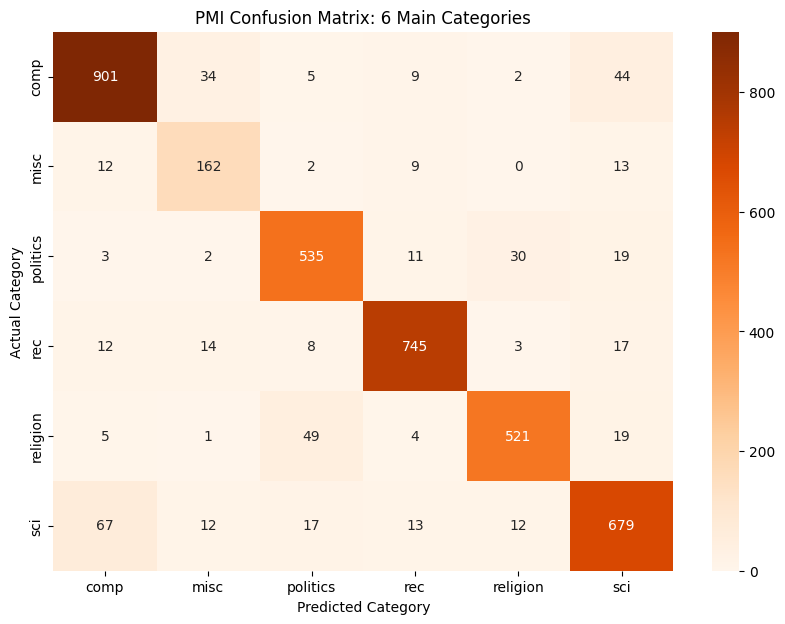

In [137]:
cm_pmi = confusion_matrix(y_test_parent, parent_preds)
labels = sorted(y_test_parent.unique())

plt.figure(figsize=(10, 7))

sns.heatmap(cm_pmi, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)

plt.title('PMI Confusion Matrix: 6 Main Categories')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()